In [20]:
import pandas as pd
import numpy as np
import ast
from sklearn.model_selection import train_test_split

df = pd.read_csv("data/final.csv", sep=';')

# строки -> списки
df['val_loss'] = df['val_loss'].map(ast.literal_eval)
df['train_loss'] = df['train_loss'].map(ast.literal_eval)

# flatten если вложенные списки
df['val_loss'] = df['val_loss'].map(lambda l: [v[0] if isinstance(v, list) else v for v in l])
df['train_loss'] = df['train_loss'].map(lambda l: [v[0] if isinstance(v, list) else v for v in l])

# фильтр
df = df[df['val_loss'].apply(lambda x: len(x) > 4)]
df = df[df['shift_type'].isin(['none'])]

# -------- LOSS FEATURES --------

df["loss_start"] = df["val_loss"].apply(lambda x: x[0])
df["loss_mid"] = df["val_loss"].apply(lambda x: x[len(x)//2])
df["loss_last_1"] = df["val_loss"].apply(lambda x: x[-2])
df["loss_last_2"] = df["val_loss"].apply(lambda x: x[-3])
df["loss_last_3"] = df["val_loss"].apply(lambda x: x[-4])

df["loss_acceleration"] = df["val_loss"].apply(
    lambda c: (c[-1] - c[-2]) - (c[-2] - c[-3])
)

df["loss_end"] = df["val_loss"].apply(lambda x: x[-1])
df["loss_growth"] = df["loss_end"] - df["loss_start"]
df["loss_stability"] = df["val_loss"].apply(lambda x: np.std(x[:-1]))

# -------- GAP FEATURES --------

def build_gap(train, val):
    train = np.array(train)
    val = np.array(val)

    gap = train - val

    return pd.Series({
        "gap_last": gap[-1],
        "gap_growth": gap[-1] - gap[0],
        "gap_std": np.std(gap)
    })

gap_df = df.apply(
    lambda r: build_gap(r["train_loss"], r["val_loss"]),
    axis=1
)

df = pd.concat([df, gap_df], axis=1)

# -------- CLEAN --------

df['imbalance'] = df['imbalance'].astype(int)

df = df.drop(columns=[
    "val_loss",
    "train_loss",
    "val_acc",
    "index",
    "seed"
])

# -------- FEATURES --------

X = df.drop(columns=[
    "loss_end",
    "overfitting",
    "imbalance",
    "train_acc",
    "test_acc",
    "model",
    "shift_type"
])

y = (df["loss_end"] - df["loss_last_1"]) / df["loss_last_1"]

X = X.dropna()
y = y.loc[X.index]


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(X_train.shape, X_test.shape)
print(y_train.shape, y_test.shape)

Index(['epoch', 'train_size', 'loss_start', 'loss_mid', 'loss_last_1',
       'loss_last_2', 'loss_last_3', 'loss_acceleration', 'loss_growth',
       'loss_stability', 'gap_last', 'gap_growth', 'gap_std'],
      dtype='str')
(1478, 13) (370, 13)
(1478,) (370,)


In [5]:
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, ExtraTreesRegressor
from sklearn.linear_model import LinearRegression
from sklearn.svm import LinearSVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.neural_network import MLPRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# model = RandomForestRegressor(
#     n_estimators=300,
#     random_state=42,
#     n_jobs=-1
# )
model = XGBRegressor()

model.fit(X_train, y_train)
pred = model.predict(X_test)

mae = mean_absolute_error(y_test, pred)
rmse = np.sqrt(mean_squared_error(y_test, pred))
r2 = r2_score(y_test, pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2:", r2)

MAE: 0.013708216933240534
RMSE: 0.024086560114482864
R2: 0.7396767038111198


In [6]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import pandas as pd
import numpy as np

def benchmark_regressors(models, X_train, X_test, y_train, y_test):

    results = []

    for name, model in models.items():

        # обучение
        model.fit(X_train, y_train)

        # предсказание
        pred = model.predict(X_test)

        # метрики
        r2 = r2_score(y_test, pred)
        mae = mean_absolute_error(y_test, pred)
        rmse = np.sqrt(mean_squared_error(y_test, pred))

        results.append({
            "model": name,
            "R2": r2,
            "MAE": mae,
            "RMSE": rmse,
            "mm": model
        })

    results_df = pd.DataFrame(results)
    return results_df.sort_values("R2", ascending=False)

In [7]:
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.neural_network import MLPRegressor

from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor,
    ExtraTreesRegressor,
    AdaBoostRegressor,
    HistGradientBoostingRegressor
)

models = {

    "LinearRegression": LinearRegression(),
    "Ridge": Ridge(),

    "DecisionTree": DecisionTreeRegressor(),

    "RandomForest": RandomForestRegressor(n_estimators=200),
    "ExtraTrees": ExtraTreesRegressor(n_estimators=200),

    "GradientBoosting": GradientBoostingRegressor(),
    "HistGradientBoosting": HistGradientBoostingRegressor(),

    "AdaBoost": AdaBoostRegressor(),

    "KNN": KNeighborsRegressor(n_neighbors=5),

    "SVR": SVR(),

    "MLP": MLPRegressor(max_iter=500)
}

results = benchmark_regressors(
    models,
    X_train,
    X_test,
    y_train,
    y_test
)

print(results)

                   model         R2       MAE      RMSE  \
6   HistGradientBoosting   0.746556  0.013389  0.023766   
5       GradientBoosting   0.728489  0.013654  0.024599   
3           RandomForest   0.721464  0.013485  0.024915   
4             ExtraTrees   0.702060  0.013763  0.025768   
7               AdaBoost   0.609784  0.018899  0.029490   
0       LinearRegression   0.553240  0.015046  0.031554   
1                  Ridge   0.446554  0.017050  0.035120   
2           DecisionTree   0.409479  0.019880  0.036277   
9                    SVR  -0.109166  0.027806  0.049718   
8                    KNN  -0.243160  0.028749  0.052636   
10                   MLP -27.912552  0.190780  0.253841   

                                                   mm  
6                     HistGradientBoostingRegressor()  
5   ([DecisionTreeRegressor(criterion='friedman_ms...  
3   (DecisionTreeRegressor(max_features=1.0, rando...  
4   (ExtraTreeRegressor(random_state=1616032870), ...  
7   (Decisi

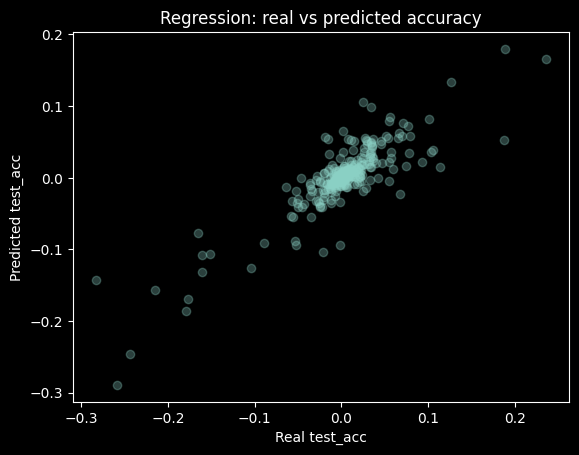

In [8]:
import matplotlib.pyplot as plt
pred = results.iloc[0]["mm"].predict(X_test)

plt.scatter(y_test, pred, alpha=0.3)

plt.xlabel("Real test_acc")
plt.ylabel("Predicted test_acc")
plt.title("Regression: real vs predicted accuracy")

# plt.plot([0,1],[0,1])
plt.show()

loss_acceleration    0.508247
loss_last_2          0.128935
gap_last             0.125412
loss_mid             0.034417
loss_last_3          0.033993
loss_start           0.030234
epoch                0.029278
gap_std              0.027094
loss_last_1          0.024819
loss_growth          0.019842
gap_growth           0.018967
loss_stability       0.016598
train_size           0.002165
dtype: float64


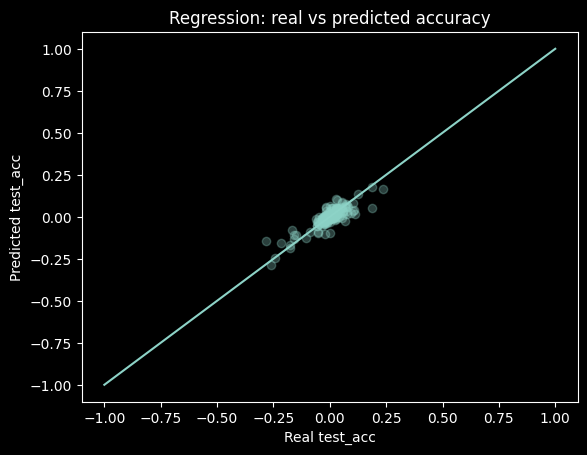

In [9]:
model_reg = RandomForestRegressor()
model_reg.fit(X_train, y_train)

importance = pd.Series(
    model_reg.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

print(importance)
model_reg = results.iloc[0]["mm"]
import matplotlib.pyplot as plt
pred =  model_reg.predict(X_test)

plt.scatter(y_test, pred, alpha=0.3)

plt.xlabel("Real test_acc")
plt.ylabel("Predicted test_acc")
plt.title("Regression: real vs predicted accuracy")

plt.plot([-1,1],[-1,1])
plt.show()

In [21]:
import numpy as np
import pandas as pd
from tensorflow.keras.callbacks import Callback, EarlyStopping


class SmartEarlyStopping(Callback):

    def __init__(self, model_meta, train_size, shift_noise=False):
        super().__init__()

        self.model_meta = model_meta
        self.train_size = train_size
        self.shift_noise = shift_noise

        self.train_loss = []
        self.val_loss = []

    def on_epoch_end(self, epoch, logs=None):

        train_loss = logs.get("loss")
        val_loss = logs.get("val_loss")

        if train_loss is None or val_loss is None:
            return

        self.train_loss.append(train_loss)
        self.val_loss.append(val_loss)

        if len(self.val_loss) < 4:
            return

        row = self.build_features(epoch)

        pred_next = self.model_meta.predict(row)[0]

        print(f"predicted next loss: {pred_next:.4f},")


        if pred_next > 0.002:
            print(f"Expected metric increase → stopping {pred_next:.4f}")
            self.model.stop_training = True

        print(
            f"epoch={epoch} "
            f"val_loss={self.val_loss[-1]:.4f} "
            f"pred={pred_next:.4f} "
        )

    def build_features(self, epoch):

        val = np.array(self.val_loss[-10:])
        train = np.array(self.train_loss[-10:])

        if len(val) < 4:
            val = np.pad(val, (4 - len(val), 0), "edge")
            train = np.pad(train, (4 - len(train), 0), "edge")

        # GAP
        gap = train - val
        row = {
            "train_size": self.train_size,
            "epoch": epoch,

            "loss_start": val[0],
            "loss_mid": val[len(val) // 2],
            "loss_last_1": val[-1],
            "loss_last_2": val[-2],
            "loss_last_3": val[-3],
            #
            "loss_acceleration": val[-1] - 2 * val[-2] + val[-3],
            "loss_growth": val[-1] - val[0],
            "loss_stability": np.std(val),
            #
            # # новые признаки
            "gap_last": gap[-1],
            "gap_growth": gap[-1] - gap[0],
            "gap_std": np.std(gap),
        }
        feature_order = [
    'epoch', 'train_size', 'loss_start', 'loss_mid', 'loss_last_1',
    'loss_last_2', 'loss_last_3', 'loss_acceleration', 'loss_growth',
    'loss_stability', 'gap_last', 'gap_growth', 'gap_std'
]
        df = pd.DataFrame([row])
        df = df[feature_order]
        return df

In [22]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.datasets import mnist

(X_train, y_train), (X_test, y_test) = mnist.load_data()

X_train = X_train.astype("float32") / 255.0
X_test  = X_test.astype("float32") / 255.0

X_train = np.expand_dims(X_train, -1)
X_test  = np.expand_dims(X_test, -1)
def build_mlp(hidden_units=128, l2=0.0):
    model = models.Sequential([
        layers.Flatten(input_shape=(28, 28, 1)),
        layers.Dense(hidden_units, activation="relu",
                     kernel_regularizer=regularizers.l2(l2)),
        layers.Dropout(0.3),
        layers.Dense(10, activation="softmax")
    ])
    return model

def build_mlp_overfit():
    model = models.Sequential([
        layers.Flatten(input_shape=(28, 28, 1)),  # вход
        layers.Dense(212, activation="relu"),     # первый скрытый слой
        # layers.Dense(212, activation="relu"),     # второй скрытый слой
        # layers.Dense(256, activation="relu"),     # третий скрытый слой
        # Сильно уменьшаем Dropout или убираем его
        # layers.Dropout(0.05),
        layers.Dense(10, activation="softmax")   # выходной слой
    ])
    return model

In [23]:
smart_stop = SmartEarlyStopping(
    model_reg,
    500
)
model_mnist = build_mlp_overfit()
model_mnist.compile(
            optimizer="adam",
            loss="sparse_categorical_crossentropy",
            metrics=["accuracy"]
        )
model_mnist.fit(
    X_train[:500],
    y_train[:500],

    validation_split=0.2,
    epochs=200,
    batch_size=10,
    callbacks=[EarlyStopping(verbose=1, patience=5)]
    # callbacks=[smart_stop]
)



Epoch 1/200


D:\MyPrograms\python\Research_Meta_Model\.venv\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.6000 - loss: 1.3854 - val_accuracy: 0.7800 - val_loss: 0.8869
Epoch 2/200
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.8975 - loss: 0.4553 - val_accuracy: 0.8200 - val_loss: 0.6491
Epoch 3/200
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9525 - loss: 0.2627 - val_accuracy: 0.8200 - val_loss: 0.6046
Epoch 4/200
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9725 - loss: 0.1707 - val_accuracy: 0.8200 - val_loss: 0.5471
Epoch 5/200
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9900 - loss: 0.1088 - val_accuracy: 0.8400 - val_loss: 0.5444
Epoch 6/200
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 1.0000 - loss: 0.0765 - val_accuracy: 0.8500 - val_loss: 0.5523
Epoch 7/200
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 1.0000 - loss: 0.0535 - val_accuracy: 0.8600 - val_loss: 0.5561
Epoch 8/200
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 1.0000 - loss: 0.0394 - val_accuracy: 0.8600 - val_los

In [24]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.callbacks import EarlyStopping

def run_experiment(X, y, train_size, callback):

    model = build_mlp_overfit()

    model.compile(
        optimizer="adam",
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    history = model.fit(
        X[:train_size],
        y[:train_size],
        validation_split=0.2,
        epochs=200,
        batch_size=10,
        verbose=0,
        callbacks=[callback]
    )

    return history

In [25]:
from tensorflow.keras.callbacks import EarlyStopping

def run_training(X, y, train_size, callback):

    model = build_mlp_overfit()

    model.compile(
        optimizer="adam",
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    history = model.fit(
        X[:train_size],
        y[:train_size],
        validation_split=0.2,
        epochs=200,
        batch_size=10,
        verbose=0,
        callbacks=[callback]
    )

    epochs = len(history.history["loss"])

    # качество на тесте
    test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)

    best_val_loss = min(history.history["val_loss"])

    return {
        "epochs": epochs,
        "test_acc": test_acc,
        "test_loss": test_loss,
        "best_val_loss": best_val_loss
    }

In [26]:
sizes = [100, 200, 500, 1000, 2000]
runs = 5

results = []

for size in sizes:

    for r in range(runs):

        early = EarlyStopping(
            monitor="val_loss",
            patience=5
        )

        smart = SmartEarlyStopping(
            model_reg,
            size
        )

        res_early = run_training(X_train, y_train, size, early)
        res_smart = run_training(X_train, y_train, size, smart)

        results.append({
            "train_size": size,
            "run": r,

            "early_epochs": res_early["epochs"],
            "early_acc": res_early["test_acc"],
            "early_loss": res_early["test_loss"],

            "smart_epochs": res_smart["epochs"],
            "smart_acc": res_smart["test_acc"],
            "smart_loss": res_smart["test_loss"],
        })

df = pd.DataFrame(results)

D:\MyPrograms\python\Research_Meta_Model\.venv\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


predicted next loss: 0.0792,
Expected metric increase → stopping 0.0792
epoch=3 val_loss=0.5290 pred=0.0792 


D:\MyPrograms\python\Research_Meta_Model\.venv\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


predicted next loss: 0.0761,
Expected metric increase → stopping 0.0761
epoch=3 val_loss=0.6327 pred=0.0761 


D:\MyPrograms\python\Research_Meta_Model\.venv\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


...

predicted next loss: -0.0393,
epoch=3 val_loss=0.2174 pred=-0.0393 
predicted next loss: 0.1143,
Expected metric increase → stopping 0.1143
epoch=4 val_loss=0.2470 pred=0.1143 


D:\MyPrograms\python\Research_Meta_Model\.venv\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


predicted next loss: -0.0770,
epoch=3 val_loss=0.2071 pred=-0.0770 
predicted next loss: 0.0843,
Expected metric increase → stopping 0.0843
epoch=4 val_loss=0.2225 pred=0.0843 


D:\MyPrograms\python\Research_Meta_Model\.venv\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


predicted next loss: 0.0628,
Expected metric increase → stopping 0.0628
epoch=3 val_loss=0.2374 pred=0.0628 


            early_acc  smart_acc  early_loss  smart_loss  early_epochs  \
train_size                                                               
100           0.68594    0.64544    1.146604    1.192893          33.6   
200           0.74018    0.72068    0.934710    0.909228          17.6   
500           0.83208    0.81634    0.588642    0.606039          12.0   
1000          0.88184    0.87282    0.409022    0.417913           8.6   
2000          0.90862    0.89974    0.347711    0.340650          13.2   

            smart_epochs  diff_epochs  
train_size                             
100                  4.0         29.6  
200                  4.0         13.6  
500                  4.4          7.6  
1000                 4.2          4.4  
2000                 4.6          8.6  


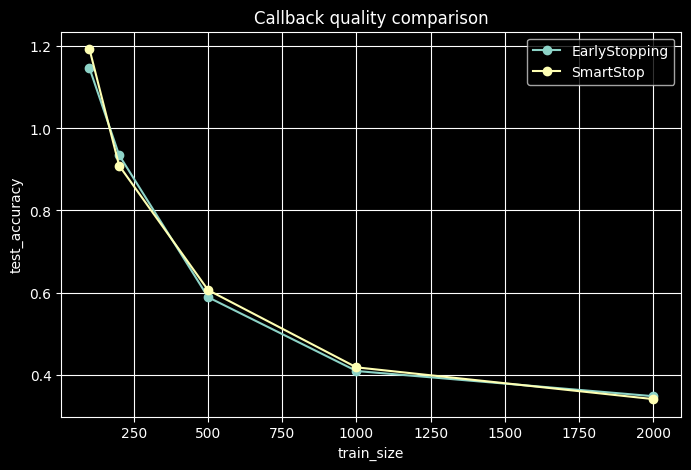

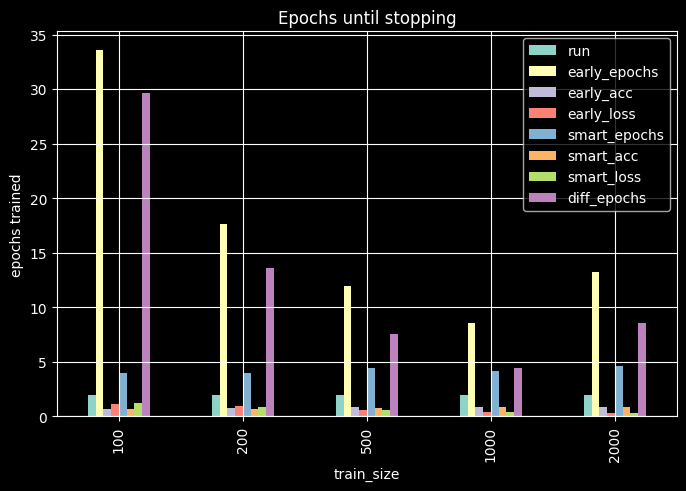

In [29]:
df['diff_epochs'] = df['early_epochs'] - df['smart_epochs']
summary = df.groupby("train_size").mean()

print(summary[[
    "early_acc",
    "smart_acc",
    "early_loss",
    "smart_loss",
    "early_epochs",
    "smart_epochs", "diff_epochs"
]])
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(summary.index, summary["early_loss"], marker="o", label="EarlyStopping")
plt.plot(summary.index, summary["smart_loss"], marker="o", label="SmartStop")

plt.xlabel("train_size")
plt.ylabel("test_accuracy")
plt.title("Callback quality comparison")

plt.legend()
plt.grid()

plt.show()
import matplotlib.pyplot as plt

summary.plot(kind="bar", figsize=(8,5))

plt.ylabel("epochs trained")
plt.title("Epochs until stopping")
plt.grid()

plt.show()

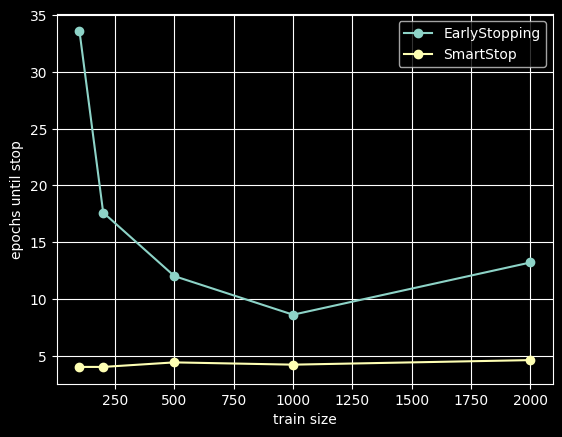

In [28]:
import matplotlib.pyplot as plt

plt.plot(summary.index, summary["early_epochs"], marker="o", label="EarlyStopping")
plt.plot(summary.index, summary["smart_epochs"], marker="o", label="SmartStop")

plt.xlabel("train size")
plt.ylabel("epochs until stop")

plt.legend()
plt.grid()

plt.show()